# LIBRARY

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [24]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

In [25]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [26]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [27]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [28]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [30]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [31]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [32]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8378,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8379,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8380,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [33]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


# Data Preparation

In [34]:
X.shape

(8382, 17)

In [35]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [36]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [37]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

## Data Partitioning

In [38]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [40]:
X_train.shape

(5867, 17)

In [41]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [42]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [44]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# CASCADE

## model

In [75]:
param_list = {
    'C':            [0.001,0.01,0.1, 1, 10, 100],
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'solver':       ['saga'],
    'l1_ratio':     np.linspace(0, 1, 10).tolist(),
    'class_weight': ['balanced', None]
}

In [76]:
def train_one_step(X_train, y_binary, X_test, y_test_binary, step_name,
                   n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
        LogisticRegression(random_state=random_state),
        param_distributions=param_list,       # ← list of dicts (valid combos)
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',                  # ← surface errors immediately
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]  # ← P(positive class)
                                                             #   only 2 columns in binary

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return best_model

## split 

In [77]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [78]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [79]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [80]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [81]:
# from imblearn.over_sampling import SMOTE
# over_dic={0:3500}
# #under_dic={0:3000}
# over = SMOTE(random_state=42, sampling_strategy=over_dic)
# #under = TomekLinks(sampling_strategy='majority')
# X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
# print('Resampled dataset shape %s' % Counter(y_res))


  STEP: sii=0
  Training samples : 5867
  Positive class   : 4056 samples
  Negative class   : 1811 samples



  Best params : {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.0, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.6116
  Test F1     : 0.6600


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1

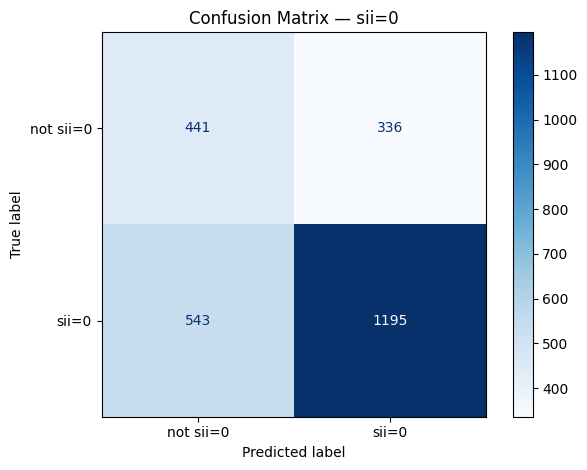

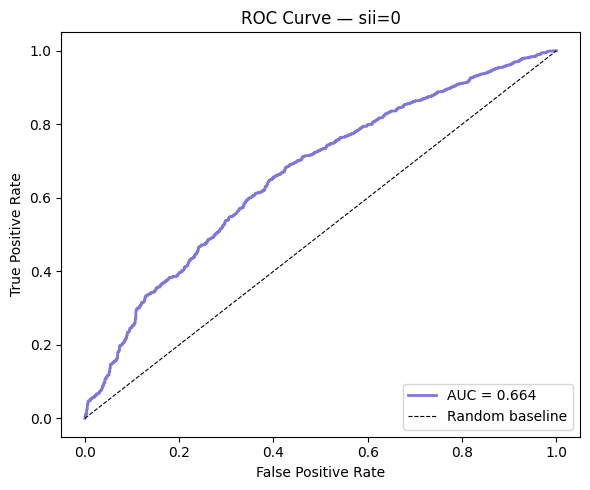

              precision    recall  f1-score   support

   not sii=0       0.45      0.57      0.50       777
       sii=0       0.78      0.69      0.73      1738

    accuracy                           0.65      2515
   macro avg       0.61      0.63      0.62      2515
weighted avg       0.68      0.65      0.66      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 441
    FP (false positives)   : 336
    FN (false negatives)   : 543
    TP (correct positives) : 1195
    AUC                    : 0.6635


In [82]:
models[0] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=0')

In [83]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1531 samples


### class 1 

In [84]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [85]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1320

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    543      0.4114       41.14
sii=1.0    470      0.3561       35.61
sii=2.0    281      0.2129       21.29
sii=3.0     26      0.0197        1.97


In [86]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [87]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    850      0.6439       64.39
binary=1    470      0.3561       35.61



  STEP: sii=1
  Training samples : 1811
  Positive class   : 1097 samples
  Negative class   : 714 samples

  Best params : {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.4444444444444444, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.5770
  Test F1     : 0.6328


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


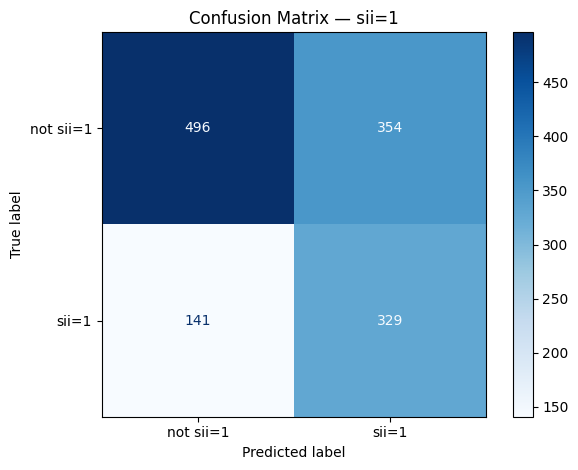

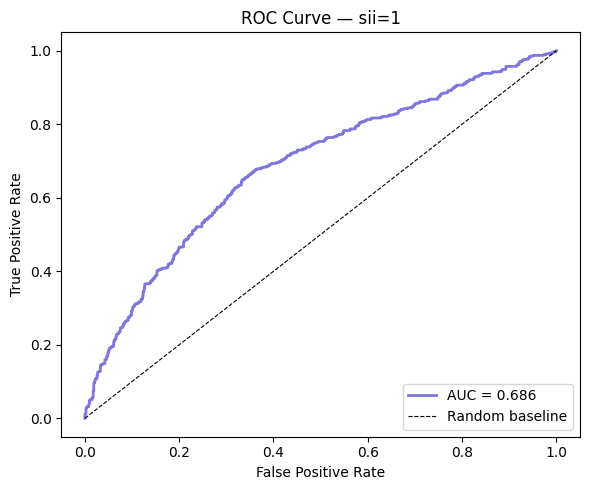

              precision    recall  f1-score   support

   not sii=1       0.78      0.58      0.67       850
       sii=1       0.48      0.70      0.57       470

    accuracy                           0.62      1320
   macro avg       0.63      0.64      0.62      1320
weighted avg       0.67      0.62      0.63      1320


  Confusion Matrix breakdown:
    TN (correct negatives) : 496
    FP (false positives)   : 354
    FN (false negatives)   : 141
    TP (correct positives) : 329
    AUC                    : 0.6863


In [88]:
models[1] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=1')

In [89]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 683 samples


### class 2

In [90]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [91]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 991

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    543      0.5479       54.79
sii=1.0    141      0.1423       14.23
sii=2.0    281      0.2836       28.36
sii=3.0     26      0.0262        2.62


In [92]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [93]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    710      0.7164       71.64
binary=1    281      0.2836       28.36


In [94]:
from imblearn.over_sampling import SMOTE
over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 655, 0: 500})


In [95]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0    500      0.4329       43.29
binary=1    655      0.5671       56.71

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    710      0.7164       71.64
binary=1    281      0.2836       28.36



  STEP: sii=2
  Training samples : 1155
  Positive class   : 655 samples
  Negative class   : 500 samples

  Best params : {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.5555555555555556, 'class_weight': 'balanced', 'C': 10}
  Best CV F1  : 0.6499
  Test F1     : 0.4952


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.5555555555555556. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was r

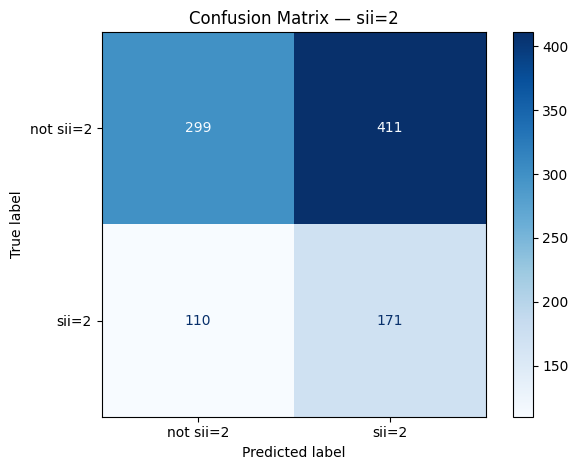

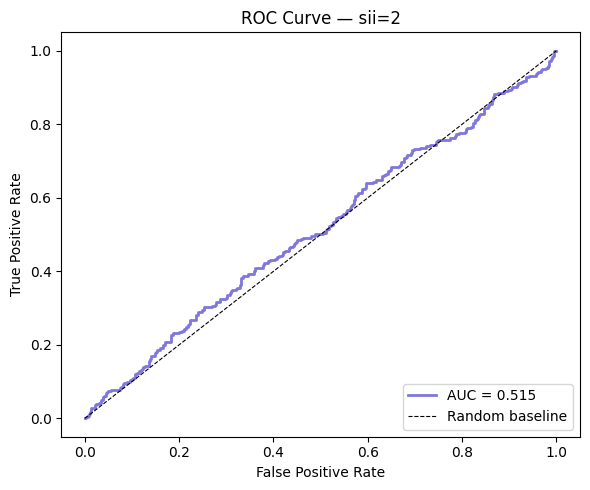

              precision    recall  f1-score   support

   not sii=2       0.73      0.42      0.53       710
       sii=2       0.29      0.61      0.40       281

    accuracy                           0.47       991
   macro avg       0.51      0.51      0.47       991
weighted avg       0.61      0.47      0.50       991


  Confusion Matrix breakdown:
    TN (correct negatives) : 299
    FP (false positives)   : 411
    FN (false negatives)   : 110
    TP (correct positives) : 171
    AUC                    : 0.5150


In [96]:
models[2] = train_one_step(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [97]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 582 samples


### class 3 

In [98]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 820


In [99]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 820 samples (all remaining)


# RESULTS

In [100]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1195 336 543     0.7805  0.6876 0.7311
   sii=1 vs [2,3]       1320         470  329 354 141     0.4817  0.7000 0.5707
     sii=2 vs [3]        991         281  171 411 110     0.2938  0.6085 0.3963
sii=3 (remaining)        820          26   26 794   0     0.0317  1.0000 0.0615


In [101]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.69      0.81      1738
       sii=1       1.00      0.70      0.82       470
       sii=2       1.00      0.61      0.76       281
       sii=3       0.03      1.00      0.06        26

    accuracy                           0.68      2515
   macro avg       0.76      0.75      0.61      2515
weighted avg       0.99      0.68      0.80      2515



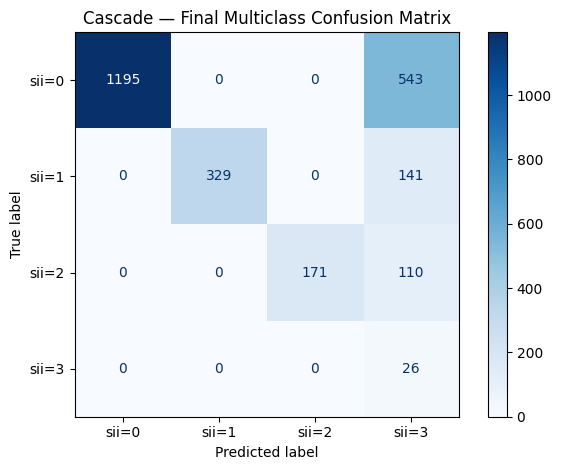

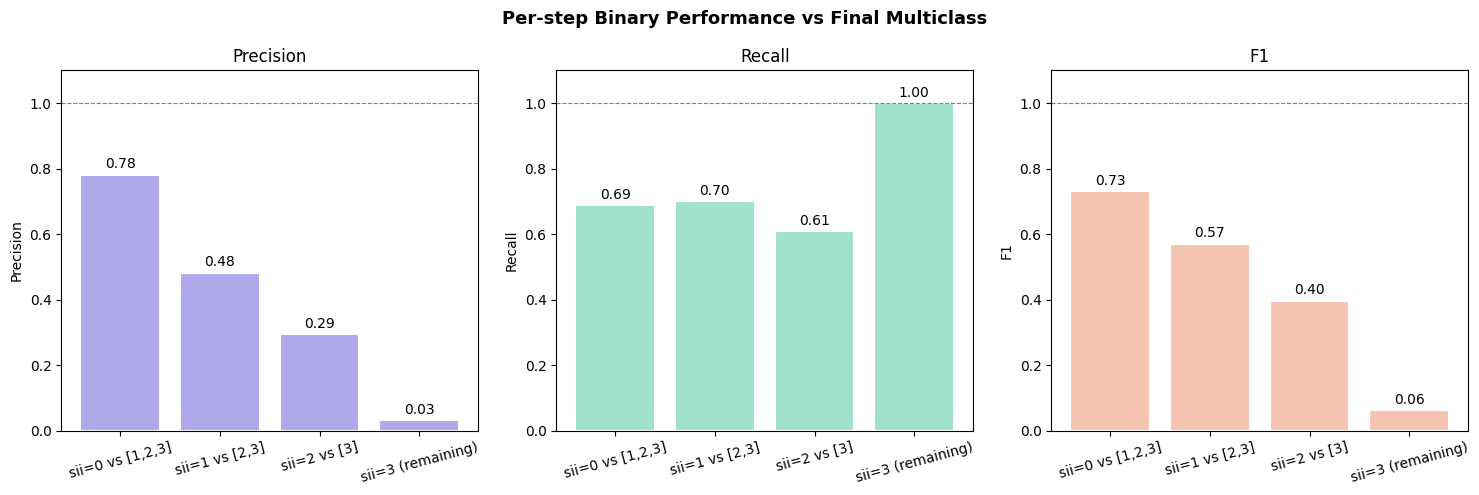

In [102]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [103]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1195
  sii=1 → true: 470    predicted: 329
  sii=2 → true: 281    predicted: 171
  sii=3 → true: 26     predicted: 820


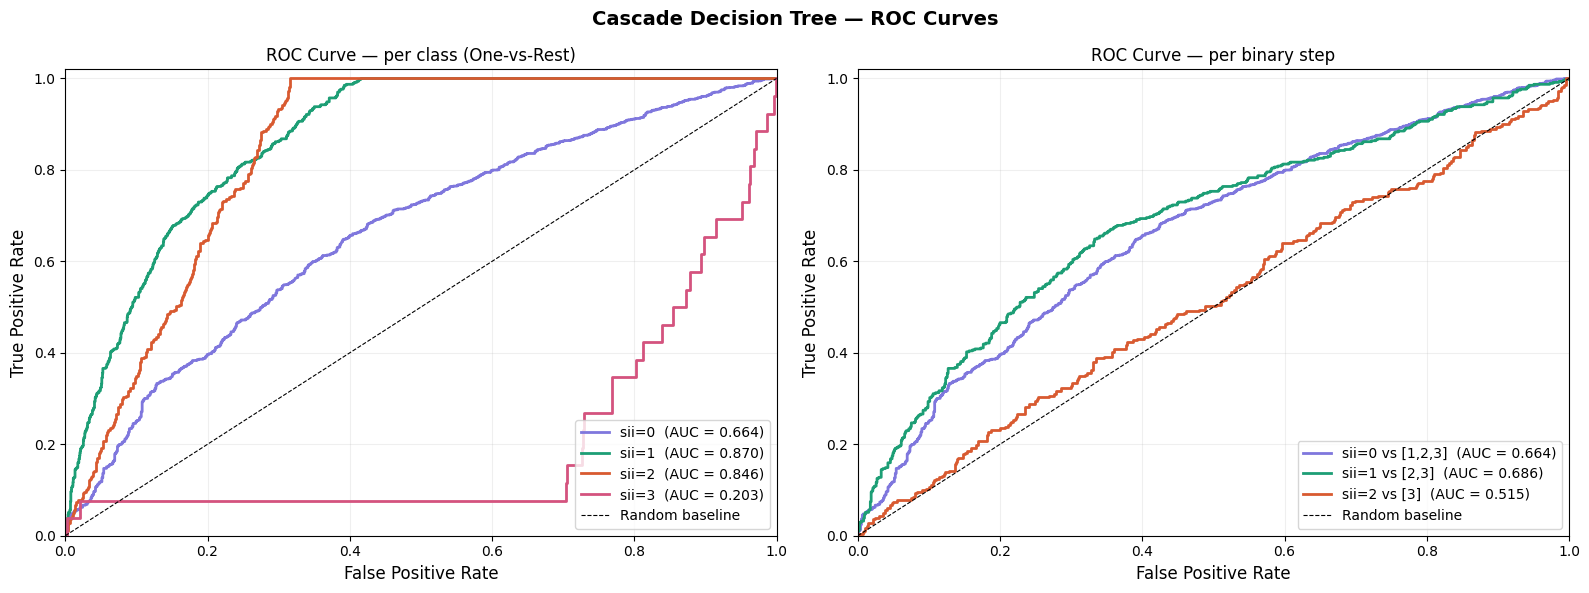


  AUC SUMMARY
  sii=0    → AUC = 0.6635
  sii=1    → AUC = 0.8696
  sii=2    → AUC = 0.8459
  sii=3    → AUC = 0.2031

  Macro AUC    : 0.6455
  Weighted AUC : 0.7176


In [104]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

## prove
